<!-- ## Introduction -->

<!-- The name of housing unit types are specific of the Italian market, therefore I create a short dictionary with its translation in English:
- Monolocale: studio flat(one-room apartment)
- Bilocale: two-rooms apartment       
- Trilocale: three-rooms apartment       
- Quadrilocale: four-rooms apartment
- Appartamento: flat/apartment (that is from four to more rooms) 
- Attico: attic           
- Villa: house/villa
- Palazzo: building/palace
- Mansarda: mansard        
- Loft: loft apartment       
- Terratetto: this is a typical italian building of the early year of the 20th century. It means "from the ground to the roof"      
- Open space: open space apartment  
- Casale: farmhouse -->

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
# import seaborn as sns

import math
import time
import optuna

# from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import  mean_absolute_error, r2_score, mean_absolute_percentage_error, mean_squared_error

# from xgboost import XGBRegressor 

from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

In [107]:
df_italia = pd.read_csv('D002_CLEANED_DATASET_RENT_ITALY.csv')

df_italia

,Price,Surface,City,Housing_unit,city_size,macroregion,floor,num_rooms,surface_bracket
0,8500.0,250.0,Milano,Appartamento,big,north,3.0,6,large
1,1150.0,40.0,Milano,Monolocale,big,north,3.0,1,small
2,900.0,51.0,Milano,Bilocale,big,north,3.0,2,small
3,1550.0,55.0,Milano,Bilocale,big,north,3.0,2,small
4,920.0,45.0,Milano,Bilocale,big,north,3.0,2,small
...,...,...,...,...,...,...,...,...,...
10662,850.0,65.0,Modena,Mansarda,mid-small,north,4.0,2,small
10663,1500.0,140.0,Modena,Attico,mid-small,north,4.0,4,mid
10664,600.0,25.0,Modena,Bilocale,mid-small,north,4.0,2,very small
10665,850.0,70.0,Modena,Bilocale,mid-small,north,4.0,2,mid-small


<!-- ## Remove outliers and suspicious values -->

<!-- Outliers are removed using the IQR and and some suspicious values are deleted. 
For suspicious values I mean those houses/flats with:
- Price rent < 150, because they are probably daily or weekly rents in B&B, while I am focusing on monthly rents 
- Surface < 20 m2, because they are more likely to be scams since they are too small to be said livable -->

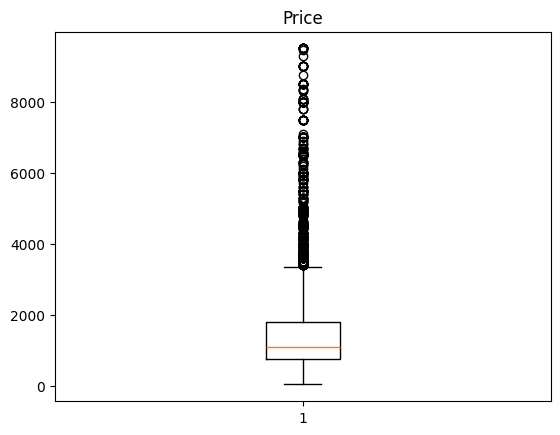

In [108]:
plt.boxplot(df_italia['Price'])
plt.title('Price');

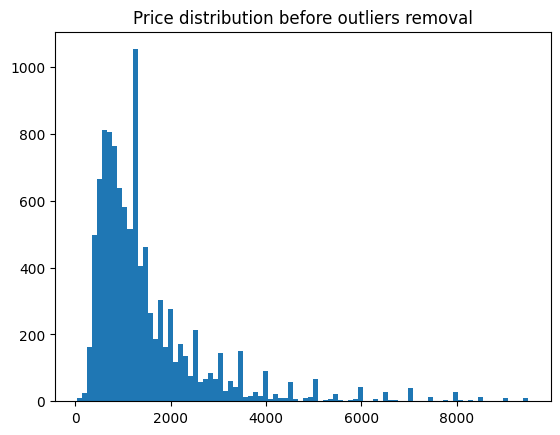

In [109]:
plt.hist(df_italia['Price'], bins = 90)
plt.title('Price distribution before outliers removal');

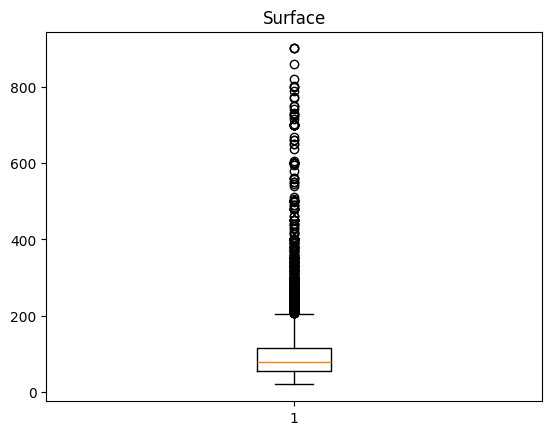

In [110]:
plt.boxplot(df_italia['Surface'])
plt.title('Surface');

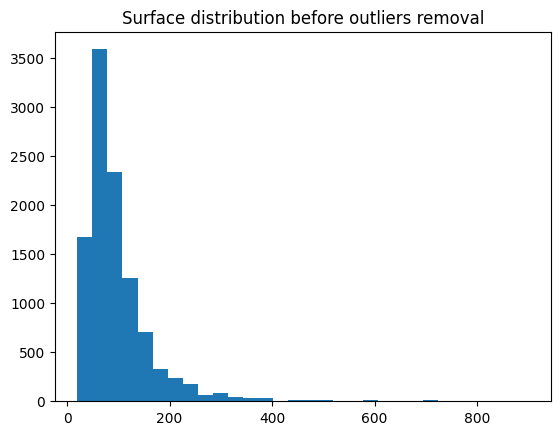

In [111]:
plt.hist(df_italia['Surface'], bins = 30)
plt.title('Surface distribution before outliers removal');

In [112]:
len(df_italia[df_italia['Price']<250]), len(df_italia[df_italia['Surface']<20])

(24, 0)

In [113]:
#Removing suspicious values, that could be scam announcements or daily/weekly rents in B&B
df_italia =df_italia[(df_italia['Surface']>=20) & (df_italia['Price']>=250)]

In [114]:
df_italia.shape

(10643, 9)

In [115]:
def remove_outliers_iqr(df,columns):
    for col in columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df


columns_to_check = ['Price','Surface']
df_cleaned = remove_outliers_iqr(df_italia, columns_to_check)

df_cleaned.head()

,Price,Surface,City,Housing_unit,city_size,macroregion,floor,num_rooms,surface_bracket
1,1150.0,40.0,Milano,Monolocale,big,north,3.0,1,small
2,900.0,51.0,Milano,Bilocale,big,north,3.0,2,small
3,1550.0,55.0,Milano,Bilocale,big,north,3.0,2,small
4,920.0,45.0,Milano,Bilocale,big,north,3.0,2,small
5,2975.0,150.0,Milano,Quadrilocale,big,north,3.0,4,mid


In [116]:
# df_cleaned = df_italia.copy()
df_cleaned.shape

(9421, 9)

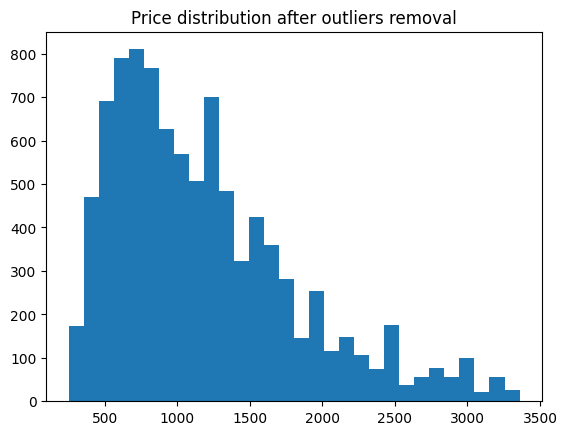

In [117]:
plt.hist(df_cleaned['Price'], bins = 30)
plt.title('Price distribution after outliers removal');

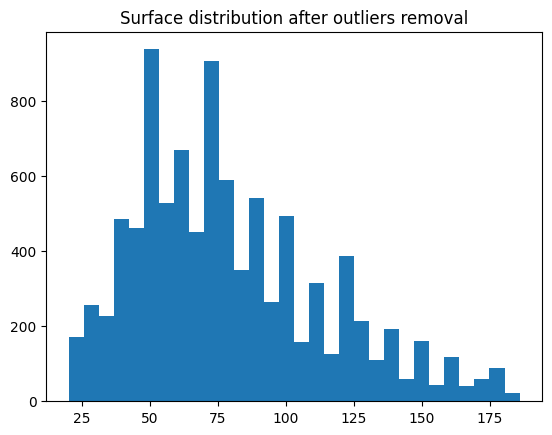

In [118]:
plt.hist(df_cleaned['Surface'], bins = 30)
plt.title('Surface distribution after outliers removal');

In [119]:
df_cleaned.columns

Index(['Price', 'Surface', 'City', 'Housing_unit', 'city_size', 'macroregion',
       'floor', 'num_rooms', 'surface_bracket'],
      dtype='str')

In [120]:
df_cleaned.groupby(['city_size','City'])['Price'].count()

city_size  City   
big        Milano     1701
           Napoli      547
           Roma       1593
mid        Bari        104
           Bologna     739
           Brescia     105
           Catania     154
           Firenze     581
           Messina     162
           Padova      179
           Prato        38
           Taranto      89
           Trieste     129
           Venezia     222
           Verona      218
mid-big    Genova      681
           Palermo     369
           Torino     1393
mid-small  Modena      172
           Parma       245
Name: Price, dtype: int64

In [121]:
df_cleaned.groupby(['city_size'])['Price'].count()

city_size
big          3841
mid          2720
mid-big      2443
mid-small     417
Name: Price, dtype: int64

<!-- # Oversampling with synthethic data -->

In [122]:
print(df_cleaned.groupby(['City','city_size', 'macroregion'])['Price'].mean().reset_index().drop('Price', axis = 1).to_dict())

{'City': {0: 'Bari', 1: 'Bologna', 2: 'Brescia', 3: 'Catania', 4: 'Firenze', 5: 'Genova', 6: 'Messina', 7: 'Milano', 8: 'Modena', 9: 'Napoli', 10: 'Padova', 11: 'Palermo', 12: 'Parma', 13: 'Prato', 14: 'Roma', 15: 'Taranto', 16: 'Torino', 17: 'Trieste', 18: 'Venezia', 19: 'Verona'}, 'city_size': {0: 'mid', 1: 'mid', 2: 'mid', 3: 'mid', 4: 'mid', 5: 'mid-big', 6: 'mid', 7: 'big', 8: 'mid-small', 9: 'big', 10: 'mid', 11: 'mid-big', 12: 'mid-small', 13: 'mid', 14: 'big', 15: 'mid', 16: 'mid-big', 17: 'mid', 18: 'mid', 19: 'mid'}, 'macroregion': {0: 'south', 1: 'north', 2: 'north', 3: 'south', 4: 'center', 5: 'north', 6: 'south', 7: 'north', 8: 'north', 9: 'south', 10: 'north', 11: 'south', 12: 'north', 13: 'center', 14: 'center', 15: 'south', 16: 'north', 17: 'north', 18: 'north', 19: 'north'}}


In [123]:
city_info = {
            'Bari':{"macroregion": "south", "city_size": 'mid'},
            'Bologna':{"macroregion": "north", "city_size": 'mid'}, 
            'Brescia':{"macroregion": "north", "city_size": 'mid'}, 
            'Catania':{"macroregion": "south", "city_size": 'mid'},  
            'Firenze':{"macroregion": "center", "city_size": 'mid'},  
            'Genova':{"macroregion": "north", "city_size": 'mid-big'},  
            'Messina':{"macroregion": "south", "city_size": 'mid'},  
            'Milano':{"macroregion": "north", "city_size": 'big'},  
            'Modena':{"macroregion": "north", "city_size": 'mid-small'},  
            'Napoli':{"macroregion": "south", "city_size": 'big'},  
            'Padova':{"macroregion": "north", "city_size": 'mid'},  
            'Palermo':{"macroregion": "south", "city_size": 'mid-big'},  
            'Parma':{"macroregion": "north", "city_size": 'mid-small'},  
            'Prato':{"macroregion": "center", "city_size": 'mid'},  
            'Roma':{"macroregion": "center", "city_size": 'big'},  
            'Taranto':{"macroregion": "south", "city_size": 'mid'},  
            'Torino':{"macroregion": "north", "city_size": 'mid-big'},  
            'Trieste':{"macroregion": "north", "city_size": 'mid'},  
            'Venezia':{"macroregion": "north", "city_size": 'mid'},  
            'Verona':{"macroregion": "north", "city_size": 'mid'} 
            } 

In [139]:
df_cleaned.groupby(['City','city_size', 
                    'macroregion', 'Housing_unit'])['Price'].agg(['mean', 'max', 
                                                                  'min','std']).reset_index().rename(columns ={'mean':'mean_price', 
                                                                                                               'max': 'max_price',
                                                                                                               'min': 'min_price',
                                                                                                               'std': 'std_price'}).to_excel('stats_rent_prices.xlsx', index= False)

In [140]:
df_cleaned.groupby(['City','city_size', 
                    'macroregion', 'Housing_unit'])['Surface'].agg(['mean', 'max', 
                                                                  'min','std']).reset_index().rename(columns ={'mean':'mean_surface', 
                                                                                                               'max': 'max_surface',
                                                                                                               'min': 'min_surface',
                                                                                                               'std': 'std_surface'}).to_excel('stats_rent_surface.xlsx', index= False)

In [141]:
price_stats = pd.read_excel("stats_rent_prices.xlsx")
surface_stats = pd.read_excel("stats_rent_Surface.xlsx")

# price_stats.head(), surface_stats.head()

In [142]:
def generate_surface(city, housing_unit):
    row = surface_stats[
        (surface_stats["City"] == city) &
        (surface_stats["Housing_unit"] == housing_unit)
    ].iloc[0]

    surface = np.random.normal(
        loc=row["mean_surface"],
        scale=row["std_surface"]
    )

    return np.clip(surface, row["min_surface"], row["max_surface"])


In [143]:
def surface_bracket(surface):
    if surface < 40:
        return "very small"
    elif surface < 70:
        return "small"
    elif surface < 100:
        return "mid-small"
    elif surface < 200:
        return "mid"
    elif surface < 200:
        return "large"
    else:
        "very large"

In [144]:
# def surface_bracket(df):
#     bins = [-np.inf, 40, 70, 100, 200, 400, np.inf]
#     labels = [
#         "very small",
#         "small",
#         "mid-small",
#         "mid",
#         "large",
#         "very large"
#     ]

#     df["surface_bracket"] = pd.cut(
#         df["Surface"],
#         bins=bins,
#         labels=labels,
#         right=False
#     )


In [145]:
def num_rooms_from_surface(surface):
    if surface < 40:
        return np.random.choice([1, 2], p=[0.8, 0.2])
    elif surface < 70:
        return np.random.choice([2, 3], p=[0.7, 0.3])
    elif surface < 100:
        return np.random.choice([3, 4], p=[0.6, 0.4])
    else:
        return np.random.choice([4, 5], p=[0.7, 0.3])


In [146]:
def generate_floor():
    floors = [-1, 0, 1, 2, 3, 4, 5]
    probs  = [0.05, 0.15, 0.25, 0.20, 0.15, 0.10, 0.10]
    return np.random.choice(floors, p=probs)


In [147]:
# def generate_price(city, housing_unit, surface):
#     row = price_stats[
#         (price_stats["City"] == city) &
#         (price_stats["Housing_unit"] == housing_unit)
#     ].iloc[0]

#     price_per_sqm = np.random.normal(
#         loc=row["mean_price_sqm"],
#         scale=row["std_price_sqm"]
#     )

#     price = price_per_sqm * surface

#     return np.clip(price, row["min_price"], row["max_price"])


In [148]:
def generate_price(city, housing_unit, surface):
    row = price_stats[
        (price_stats["City"] == city) &
        (price_stats["Housing_unit"] == housing_unit)
    ].iloc[0]

    # 1️⃣ prezzo base dalla distribuzione reale
    base_price = np.random.normal(
        loc=row["mean_price"],
        scale=row["std_price"]
    )

    # 2️⃣ superficie media osservata
    mean_surface = surface_stats[
        (surface_stats["City"] == city) &
        (surface_stats["Housing_unit"] == housing_unit)
    ]["mean_surface"].iloc[0]

    # 3️⃣ elasticità superficie-prezzo
    alpha = np.random.uniform(0.85, 1.05)

    price = base_price * (surface / mean_surface) ** alpha

    return np.clip(price, row["min_price"], row["max_price"])


In [149]:
def generate_synthetic_data(n=10_000):
    cities = list(city_info.keys())
    housing_units = ["Monolocale", "Bilocale", "Trilocale", "Appartamento"]

    rows = []

    for _ in range(n):
        city = np.random.choice(cities)
        housing = np.random.choice(housing_units, p=[0.25, 0.35, 0.25, 0.15])

        surface = generate_surface(city, housing)

        rows.append({
            "City": city,
            "macroregion": city_info[city]["macroregion"],
            "city_size": city_info[city]["city_size"],
            "Housing_unit": housing,
            "Surface": round(surface, 1),
            "surface_bracket": surface_bracket(surface),
            "num_rooms": num_rooms_from_surface(surface),
            "floor": generate_floor(),
            "Price": round(generate_price(city, housing, surface), 0)
        })

    

    return pd.DataFrame(rows)


In [150]:
synthetic_df = generate_synthetic_data(20_000)
synthetic_df.head()

,City,macroregion,city_size,Housing_unit,Surface,surface_bracket,num_rooms,floor,Price
0,Padova,north,mid,Bilocale,52.5,small,3,1,797.0
1,Prato,center,mid,Bilocale,48.4,small,3,-1,650.0
2,Parma,north,mid-small,Trilocale,73.4,mid-small,4,5,613.0
3,Catania,south,mid,Appartamento,185.0,mid,4,2,1640.0
4,Modena,north,mid-small,Monolocale,20.0,very small,1,1,285.0


<!-- # Model Building -->

In [151]:
synthetic_df = synthetic_df[['Price', 'Surface', 'City', 'Housing_unit', 'city_size', 'macroregion',
                            'floor', 'num_rooms', 'surface_bracket']]

In [152]:
df_cleaned.shape, synthetic_df.shape

((9421, 9), (20000, 9))

<!-- ## Data preparation -->

In [153]:
df_cleaned.info()


<class 'pandas.DataFrame'>
Index: 9421 entries, 1 to 10666
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Price            9421 non-null   float64
 1   Surface          9421 non-null   float64
 2   City             9421 non-null   str    
 3   Housing_unit     9421 non-null   str    
 4   city_size        9421 non-null   str    
 5   macroregion      9421 non-null   str    
 6   floor            9420 non-null   float64
 7   num_rooms        9421 non-null   int64  
 8   surface_bracket  9421 non-null   str    
dtypes: float64(3), int64(1), str(5)
memory usage: 736.0 KB


In [154]:
df_cleaned.select_dtypes(include='object').columns

Index(['City', 'Housing_unit', 'city_size', 'macroregion', 'surface_bracket'], dtype='str')

In [155]:
df_cleaned.select_dtypes(include=['float64','int64']).columns

Index(['Price', 'Surface', 'floor', 'num_rooms'], dtype='str')

In [156]:
categorical_cols = ['City', 
                    'Housing_unit', 
                    'city_size', 
                    'macroregion', 
                    'surface_bracket']

numeric_cols = ['Surface', 
                'floor', 
                'num_rooms']

features = categorical_cols + numeric_cols

target = ['Price']

In [157]:
df_cleaned[categorical_cols] = df_cleaned[categorical_cols].astype('category')
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].astype(float)
synthetic_df[categorical_cols] = synthetic_df[categorical_cols].astype('category')
synthetic_df[numeric_cols] = synthetic_df[numeric_cols].astype(float)

In [159]:
X = df_cleaned.drop(columns = ['Price'])
y = df_cleaned['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 42)
X_train.shape, X_test.shape, X.shape

((7536, 8), (1885, 8), (9421, 8))

In [166]:
df_train = pd.concat([X_train, y_train], axis = 1)
df_train_val = pd.concat([df_train, synthetic_df ], axis = 0)

In [187]:
df_train_val[categorical_cols] = df_train_val[categorical_cols].astype('category')
df_train_val[numeric_cols] = df_train_val[numeric_cols].astype(float)

In [188]:
df_train_val.info()

<class 'pandas.DataFrame'>
Index: 27536 entries, 3705 to 19999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Surface          27536 non-null  float64 
 1   City             27536 non-null  category
 2   Housing_unit     27536 non-null  category
 3   city_size        27536 non-null  category
 4   macroregion      27536 non-null  category
 5   floor            27535 non-null  float64 
 6   num_rooms        27536 non-null  float64 
 7   surface_bracket  27536 non-null  category
 8   Price            27536 non-null  float64 
dtypes: category(5), float64(4)
memory usage: 1.2 MB


In [189]:
X_train_val = df_train_val.drop(columns = ['Price'])
y_train_val = df_train_val['Price']

In [190]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, train_size=0.9, random_state = 42)
X_train.shape, X_val.shape, X.shape

((24782, 8), (2754, 8), (27536, 8))

In [191]:
# 

In [192]:
X_train.shape, X_val.shape, X_test.shape, X.shape

((24782, 8), (2754, 8), (1885, 8), (27536, 8))

In [193]:
# # import optuna
# import lightgbm as lgb
# import numpy as np
# # import pandas as pd
# # from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_squared_error
# # from sklearn.datasets import fetch_california_housing

# # # 1. Caricamento dati di esempio (California Housing)
# # data = fetch_california_housing()
# # X = pd.DataFrame(data.data, columns=data.feature_names)
# # y = data.target

# # X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# # 2. Definizione della funzione obiettivo
# def objective(trial):
#     # Parametri da ottimizzare
#     param = {
#         "objective": "regression",
#         "metric": "rmse",
#         "verbosity": -1,
#         "boosting_type": "gbdt",
#         "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
#         "num_leaves": trial.suggest_int("num_leaves", 2, 256),
#         "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
#         "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
#         "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
#         "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
#         "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
#         "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
#     }

#     # Training del modello
#     model = LGBMRegressor(**param, n_estimators=1000)
    
#     # Utilizzo dell'early stopping per evitare overfitting
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_val, y_val)],
#         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
#     )

#     preds = model.predict(X_val)
#     rmse = np.sqrt(mean_squared_error(y_val, preds))
#     return rmse

# # 3. Creazione dello studio e ottimizzazione
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50) # Puoi aumentare n_trials per risultati migliori

# # 4. Risultati
# print("\n--- Ottimizzazione Completata ---")
# print(f"Miglior RMSE: {study.best_value:.4f}")
# print("Migliori Parametri:")
# for key, value in study.best_params.items():
#     print(f"  {key}: {value}")

In [194]:
best_params = {'learning_rate' : 0.04276630249214361
                ,'num_leaves': 220
                ,'feature_fraction': 0.6230703062842939
                ,'bagging_fraction': 0.9089138359549807
                ,'bagging_freq': 4
                ,'min_child_samples': 13
                ,'lambda_l1': 6.088830389758899e-08
                ,'lambda_l2': 0.007997489354430199}

## LGBM

In [195]:
# lgbm = LGBMRegressor()

# param_grid ={
#     'n_estimators': [50, 100, 150],
#     'learning_rate': [0.01, 0.1, 1]
# }


# grid_search = GridSearchCV(lgbm, param_grid, cv=5, scoring = 'neg_mean_squared_error') 

# grid_search.fit(X_train , y_train )

# print(grid_search.best_params_)

In [196]:
X_train.shape, y_train.shape

((24782, 8), (24782,))

## Training set

In [197]:
# With the LGBM algorithm numerical variables need to be trasnformed into float variables

params_2 ={'learning_rate': 0.1, 'n_estimators': 50}
params_1 =  {'n_estimators': 150 ,'learning_rate': 0.1}

num  = 2

lgbm_model = LGBMRegressor(**best_params, verbosity = -1) 
lgbm_model.fit(X_train , y_train )

y_train_pred = lgbm_model.predict(X_train)

mae = round( mean_absolute_error(y_train,y_train_pred), 2)
mse = round(mean_squared_error(y_train,y_train_pred), 2)
mape = round(mean_absolute_percentage_error(y_train,y_train_pred)*100,2)
r2 = round(r2_score(y_train,y_train_pred)*100,2)
rmse = round(math.sqrt(mse), 2)


print(f"MAE is: {mae}")
print(f"MSE is: {mse}")
print(f"MAPE is: {mape}")
print(f"R2 SCORE is: {r2}")
print(f"RMSE is: {rmse}")


MAE is: 252.41
MSE is: 118613.82
MAPE is: 30.12
R2 SCORE is: 65.07
RMSE is: 344.4


In [198]:
df_metrics = pd.DataFrame(columns=['Algorithm', 'MAE €', 'MSE €', 'RMSE €', 'MAPE %',   'R2 Score %' ])


In [199]:
df_metrics.loc[len(df_metrics)] = {'Algorithm':f'LGBM Regressor params_{num} no OUTLIERS TRAIN', 
                                        'MAE €':mae, 
                                        'MSE €': mse,  
                                        'RMSE €': rmse, 
                                        'MAPE %': mape, 
                                        'R2 Score %': r2 }

df_metrics

,Algorithm,MAE €,MSE €,RMSE €,MAPE %,R2 Score %
0,LGBM Regressor params_2 no OUTLIERS TRAIN,252.41,118613.82,344.4,30.12,65.07


<!-- ## Testing set -->

In [200]:
y_pred = lgbm_model.predict(X_val)

mae = round(mean_absolute_error(y_val,y_pred), 2)
mse = round(mean_squared_error(y_val,y_pred), 2)
mape = round(mean_absolute_percentage_error(y_val,y_pred)*100,2)
r2 = round(r2_score(y_val,y_pred), 2)*100
rmse =round( math.sqrt(mse), 2)


print(f"MAE is: {mae}")
print(f"MSE is: {mse}")
print(f"MAPE is: {mape}")
print(f"R2 SCORE is: {r2}")
print(f"RMSE is: {rmse}")


MAE is: 278.28
MSE is: 147271.77
MAPE is: 33.2
R2 SCORE is: 56.99999999999999
RMSE is: 383.76


In [201]:
df_metrics.loc[len(df_metrics)] = {
    'Algorithm': f'LGBM Regressor params_{num} no OUTLIERS VAL',
    'MAE €': mae,
    'MSE €': mse,
    'RMSE €': rmse,
    'MAPE %': mape,
    'R2 Score %': r2
}

In [202]:
df_metrics

,Algorithm,MAE €,MSE €,RMSE €,MAPE %,R2 Score %
0,LGBM Regressor params_2 no OUTLIERS TRAIN,252.41,118613.82,344.40,30.12,65.07
1,LGBM Regressor params_2 no OUTLIERS VAL,278.28,147271.77,383.76,33.20,57.00


In [ ]:
df_metrics

,Algorithm,MAE €,MSE €,RMSE €,MAPE %,R2 Score %
0,LGBM Regressor params_2 no OUTLIERS TRAIN,255.29,128666.47,358.70,25.63,66.57
1,LGBM Regressor params_2 no OUTLIERS VAL,278.84,150178.52,387.53,28.18,60.00


In [ ]:
# df_metrics


,Algorithm,MAE €,MSE €,RMSE €,MAPE %,R2 Score %
0,LGBM Regressor params_2 no OUTLIERS TRAIN,274.19,144702.07,380.40,26.14,65.25
1,LGBM Regressor params_2 no OUTLIERS VAL,308.11,183893.28,428.83,28.55,52.00


In [ ]:
# df_metrics


,Algorithm,MAE €,MSE €,RMSE €,MAPE %,R2 Score %
0,LGBM Regressor params_2 no OUTLIERS TRAIN,293.55,165190.19,406.44,27.97,60.33
1,LGBM Regressor params_2 no OUTLIERS VAL,311.90,187340.06,432.83,28.84,51.00


<!-- # Results Analysis -->

In [ ]:
# y_pred = pd.Series(y_pred) 


In [ ]:
# y_pred_index = pd.Series(y_val.index)

In [ ]:
# pd.DataFrame()

0       6430
1       4162
2      10515
3       2950
4       7145
       ...  
843      376
844     1079
845     7285
846      853
847     3137
Length: 848, dtype: int64

In [ ]:
# df_pred = pd.concat([y_pred_index, y_pred], axis = 1)

In [ ]:

# df_pred.columns = ["index", "y_pred"]


In [ ]:
# df_pred = df_pred.set_index("index", drop = True)

In [ ]:
# df_pred

,y_pred
index,
6430,1475.448479
4162,1101.226022
10515,1309.817142
2950,1462.524261
7145,1679.014693
...,...
376,1397.098076
1079,1346.521901
7285,1213.899475


In [ ]:
# df_results = pd.concat([X_val, y_val, df_pred], axis = 1)

In [ ]:
# df_results['absolute_error'] = np.abs(df_results['Price'] - df_results['y_pred'])

In [ ]:
# df_results

,Surface,City,Housing_unit,city_size,macroregion,floor,num_rooms,surface_bracket,Price,y_pred,rmse,error,absolut_error,absolute_error
6430,120.0,Napoli,Quadrilocale,big,south,2.0,4.0,mid,1800.0,1475.448479,432.827985,324.551521,324.551521,324.551521
4162,110.0,Torino,Appartamento,mid-big,north,3.0,5.0,mid,1100.0,1101.226022,432.827985,1.226022,1.226022,1.226022
10515,90.0,Modena,Quadrilocale,mid-small,north,2.0,4.0,mid-small,600.0,1309.817142,432.827985,709.817142,709.817142,709.817142
2950,100.0,Roma,Trilocale,big,center,3.0,3.0,mid,1650.0,1462.524261,432.827985,187.475739,187.475739,187.475739
7145,90.0,Bologna,Appartamento,mid,north,1.0,5.0,mid-small,450.0,1679.014693,432.827985,1229.014693,1229.014693,1229.014693
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,65.0,Milano,Bilocale,big,north,4.0,2.0,small,1300.0,1397.098076,432.827985,97.098076,97.098076,97.098076
1079,55.0,Milano,Bilocale,big,north,8.0,2.0,small,2300.0,1346.521901,432.827985,953.478099,953.478099,953.478099
7285,50.0,Bologna,Bilocale,mid,north,4.0,2.0,small,1350.0,1213.899475,432.827985,136.100525,136.100525,136.100525
853,55.0,Milano,Bilocale,big,north,5.0,2.0,small,1150.0,1304.615642,432.827985,154.615642,154.615642,154.615642


In [ ]:
# df_results.groupby('City')['absolute_error'].mean().sort_values(ascending=False)

City
Brescia    414.599589
Roma       410.816620
Bologna    400.904576
Firenze    371.658546
Milano     351.507183
Modena     313.561046
Venezia    300.028333
Catania    283.297434
Napoli     265.834054
Palermo    247.215953
Torino     245.162938
Parma      243.494584
Trieste    243.031471
Bari       242.502302
Messina    234.807639
Padova     210.154458
Genova     205.542508
Prato      184.428599
Verona     171.157787
Taranto    102.081186
Name: absolute_error, dtype: float64

<!-- # Saving the Pickle -->

In [ ]:
import joblib

joblib.dump(
    {
        "model": lgbm_model,
        "features": X_train.columns.tolist(),
        "pandas_version": pd.__version__
    },
    "models/lgbm_regressor_v1.pkl"
)


['models/lgbm_regressor_v1.pkl']

<!-- # Load pickle -->

In [ ]:
# def load_model(path):
#     artifact = joblib.load(path)
#     return artifact["model"], artifact["features"], artifact["pandas_version"]

# model, features, version = load_model("models/lgbm_regressor_v1.pkl")
# print(version)


2.3.3


In [ ]:
# X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7630 entries, 2269 to 9799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Surface          7630 non-null   float64 
 1   City             7630 non-null   category
 2   Housing_unit     7630 non-null   category
 3   city_size        7630 non-null   category
 4   macroregion      7630 non-null   category
 5   floor            7629 non-null   float64 
 6   num_rooms        7630 non-null   float64 
 7   surface_bracket  7630 non-null   category
dtypes: category(5), float64(3)
memory usage: 277.6 KB


In [ ]:
# X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7630 entries, 2269 to 9799
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   Surface          7630 non-null   float64 
 1   City             7630 non-null   category
 2   Housing_unit     7630 non-null   category
 3   city_size        7630 non-null   category
 4   macroregion      7630 non-null   category
 5   floor            7629 non-null   float64 
 6   num_rooms        7630 non-null   int64   
 7   rent_bracket     7630 non-null   category
 8   surface_bracket  7630 non-null   category
dtypes: category(6), float64(2), int64(1)
memory usage: 285.2 KB


In [ ]:
# 'Surface', 'City', 'Housing_unit', #'city_size', 'macroregion', 
# 'floor',  'num_rooms', #'rent_bracket', 'surface_bracket'

In [ ]:
# surface = float(input("Surface: " ))
# print(surface)

ValueError: could not convert string to float: ''

In [ ]:
# Surface = 80.0 
# City = 'Milano'
# Housing_unit = 'Trilocale' 
# floor = 3.0
# num_rooms = 3

In [ ]:
# X_train.columns

Index(['Surface', 'City', 'Housing_unit', 'city_size', 'macroregion', 'floor',
       'num_rooms', 'rent_bracket', 'surface_bracket'],
      dtype='object')

In [ ]:
# df_predict = pd.DataFrame(columns=['Surface', 'City', 'Housing_unit', 'floor',  'num_rooms'])


# df_predict.loc[len(df_predict)] = {
#     'Surface' : Surface,
#     'City': City,
#     'Housing_unit': Housing_unit,
#     'floor': floor,
#     'num_rooms':num_rooms
# }

# city_size = {
#     "Roma": "big",
#     "Milano": "big",
#     "Napoli": "big",
#     "Torino": "mid-big",
#     "Palermo": "mid-big",
#     "Genova": "mid-big",
#     "Bologna": "mid",
#     "Firenze": "mid",
#     "Bari": "mid",
#     "Catania": "mid",
#     "Verona": "mid",
#     "Venezia": "mid",
#     "Messina": "mid",
#     "Padova": "mid",
#     "Trieste": "mid",
#     "Brescia": "mid",
#     "Taranto": "mid",
#     "Prato": "mid",
#     "Parma": "mid-small",
#     "Modena": "mid-small"
# }

# df_predict["city_size"] = df_predict["City"].map(city_size)

# #######################################################################


# city_macroregion = {
#     "Milano": "north",
#     "Torino": "north",
#     "Genova": "north",
#     "Bologna": "north",
#     "Verona": "north",
#     "Venezia": "north",
#     "Padova": "north",
#     "Trieste": "north",
#     "Parma": "north",
#     "Brescia": "north",
#     "Modena": "north",
#     "Prato": "center",
#     "Roma": "center",
#     "Firenze": "center",
#     "Napoli": "south",
#     "Palermo": "south",
#     "Bari": "south",
#     "Catania": "south",
#     "Messina": "south",
#     "Taranto": "south"
# }

# df_predict["macroregion"] = df_predict["City"].map(city_macroregion)


# #######################################################################

# bins = [-np.inf, 40, 70, 100, 200, 400, np.inf]
# labels = [
#     "very small",
#     "small",
#     "mid-small",
#     "mid",
#     "large",
#     "very large"
# ]

# df_predict["surface_bracket"] = pd.cut(
#     df_predict["Surface"],
#     bins=bins,
#     labels=labels,
#     right=False
# )

# #######################################################################




# df_predict = df_predict[['Surface', 'City', 'Housing_unit', 'city_size', 'macroregion', 'floor',
#        'num_rooms', 'surface_bracket']]

KeyError: 'Price'

In [ ]:
# 

In [ ]:
# def get_user_input(features):
#     user_data = {}
#     for feature in features:    
#         user_data[feature] = float(input(f"Enter value for {feature}: "))
#     return pd.DataFrame([user_data])

# X_user = get_user_input(features)
# price = model.predict(X_user)[0]

# print(f"\n💰 Predicted price: € {price:,.2f}")

<!-- ## features -->

In [ ]:
# city_size = {
#     "Roma": "big",
#     "Milano": "big",
#     "Napoli": "big",

#     "Torino": "mid-big",
#     "Palermo": "mid-big",
#     "Genova": "mid-big",

#     "Bologna": "mid",
#     "Firenze": "mid",
#     "Bari": "mid",
#     "Catania": "mid",
#     "Verona": "mid",
#     "Venezia": "mid",
#     "Messina": "mid",
#     "Padova": "mid",
#     "Trieste": "mid",
#     "Brescia": "mid",
#     "Taranto": "mid",
#     "Prato": "mid",

#     "Parma": "mid-small",
#     "Modena": "mid-small"
# }

# df_italia["city_size"] = df_italia["City"].map(city_size)

In [ ]:

# city_macroregion = {
#     "Milano": "north",
#     "Torino": "north",
#     "Genova": "north",
#     "Bologna": "north",
#     "Verona": "north",
#     "Venezia": "north",
#     "Padova": "north",
#     "Trieste": "north",
#     "Parma": "north",
#     "Brescia": "north",
#     "Modena": "north",

#     "Prato": "center",
#     "Roma": "center",
#     "Firenze": "center",

#     "Napoli": "south",
#     "Palermo": "south",
#     "Bari": "south",
#     "Catania": "south",
#     "Messina": "south",
#     "Taranto": "south"
# }


# df_italia["macroregion"] = df_italia["City"].map(city_macroregion)



In [ ]:

# bins = [-np.inf, 40, 70, 100, 200, 400, np.inf]
# labels = [
#     "very small",
#     "small",
#     "mid-small",
#     "mid",
#     "large",
#     "very large"
# ]

# df_italia["surface_bracket"] = pd.cut(
#     df_italia["Surface"],
#     bins=bins,
#     labels=labels,
#     right=False
# )


In [ ]:
# housing_to_rooms = {
#     'Monolocale': '1',
#     'Appartamento': '5',
#     'Attico': '3',
#     'Casale': '3',
#     'Loft': '2',
#     'Mansarda': '2',
#     'Open space': '2',
#     'Palazzo': '5+',
#     'Terratetto': '5+',
#     'Villa': '5+'
# }

# df_italia['N_rooms'] = df_italia['N_rooms'].fillna(
#     df_italia['Housing_unit'].map(housing_to_rooms)
# )
